In [1]:
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty.skeleton import Skeleton
import os
import pickle
import matplotlib.pyplot as plt
import myelin_analysis
import plotly.express as px
from lookup_activity_by_pt_root_id import *

#for debugging
import importlib

In [2]:
client = CAVEclient('minnie65_public')
client.version = 1507
cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')
digital_twin_coreg_df = client.materialize.query_table('digital_twin_properties_bcm_coreg_v4')

Table Owner Notice on digital_twin_properties_bcm_coreg_v4:  For the use of this table please cite: 1) https://doi.org/10.1038/s41586-025-08829-y; Wang et al., 2025 2) https://doi.org/10.1038/s41586-025-08840-3; Ding, Fahey, and Papadopoulos et al., 2025 3) https://doi.org/10.1038/s41586-025-08790-w; MICrONS Consortium et al., 2025


In [3]:
digital_twin_coreg_df.head()

,id,created,valid,target_id,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,...,readout_loc_y,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,pt_position,bb_start_position,bb_end_position
0,4641,2025-07-30 17:51:26.519437+00:00,t,335649,6,2,6883,156.510718,336.510718,0.099423,...,0.059087,335649,2020-09-28 22:41:20.303372+00:00,t,295.861125,93747454767483710,864691135702330235,"[210784, 182032, 22673]","[nan, nan, nan]","[nan, nan, nan]"
1,12061,2025-07-30 17:52:11.181987+00:00,t,194144,8,5,8632,124.727030,304.727030,0.351441,...,-0.201346,194144,2020-09-28 22:42:01.511773+00:00,t,213.307228,83542405709639148,864691135614842827,"[136400, 170640, 17951]","[nan, nan, nan]","[nan, nan, nan]"
2,14936,2025-07-30 17:52:13.397517+00:00,t,293318,9,4,8066,84.089999,264.089999,0.059189,...,0.026081,293318,2020-09-28 22:45:23.572432+00:00,t,430.108180,90783515419343652,864691135430194992,"[189472, 119296, 26037]","[nan, nan, nan]","[nan, nan, nan]"
3,4550,2025-07-30 17:51:26.448354+00:00,t,488652,6,2,5317,2.984958,182.984958,0.182729,...,0.027254,488652,2020-09-28 22:41:44.769373+00:00,t,328.244265,104297405805551073,864691135565621079,"[287536, 142464, 19382]","[nan, nan, nan]","[nan, nan, nan]"
4,8441,2025-07-30 17:51:50.670362+00:00,t,332833,6,7,6413,86.796078,266.796078,0.379714,...,-0.083915,332833,2020-09-28 22:44:41.864456+00:00,t,274.418729,93535317407139914,864691135387371905,"[209328, 174304, 20004]","[nan, nan, nan]","[nan, nan, nan]"


In [29]:
#Goal: make 2 3d plots where each point is neuron position, and the color is it's "readout_loc_x" for one, and "readout_loc_y" for another.


# --- Preprocess positions ---
# Extract position arrays and convert to a NumPy array
positions = np.stack(digital_twin_coreg_df["pt_position"].values)

# Scale to microns: multiply by [4, 4, 40], then divide by 1000
scaling_factors = np.array([4, 4, 40]) / 1000
positions_um = positions * scaling_factors

# Add new columns for x, y, z in microns
digital_twin_coreg_df["x_um"] = positions_um[:, 0]
digital_twin_coreg_df["y_um"] = positions_um[:, 1]
digital_twin_coreg_df["z_um"] = positions_um[:, 2]

# --- Plot 1: Color by readout_loc_x ---
fig_x = px.scatter_3d(
    digital_twin_coreg_df,
    x='x_um',
    y='y_um',
    z='z_um',
    color='readout_loc_x',
    color_continuous_scale='viridis',
    opacity=0.7
)

fig_x.update_traces(marker=dict(size=2))
fig_x.update_layout(
    scene=dict(
        xaxis_title='X Position (µm)',
        yaxis_title='Y Position (µm)',
        zaxis_title='Z Position (µm)'
    ),
    title='Neuron Positions Colored by Readout Location X'
)
fig_x.show()

# --- Plot 2: Color by readout_loc_y ---
fig_y = px.scatter_3d(
    digital_twin_coreg_df,
    x='x_um',
    y='y_um',
    z='z_um',
    color='readout_loc_y',
    color_continuous_scale='viridis',
    opacity=0.7
)

fig_y.update_traces(marker=dict(size=2))
fig_y.update_layout(
    scene=dict(
        xaxis_title='X Position (µm)',
        yaxis_title='Y Position (µm)',
        zaxis_title='Z Position (µm)'
    ),
    title='Neuron Positions Colored by Readout Location Y'
)
fig_y.show()


In [37]:
#Same plot as above, but color = 'pref_ori'

#filter only OSI > .5
filtered_ori_df = digital_twin_coreg_df[digital_twin_coreg_df['OSI'] > 0.7]

fig_ori = px.scatter_3d(
    filtered_ori_df,
    x='x_um',
    y='y_um',
    z='z_um',
    color='pref_ori',
    color_continuous_scale='rainbow',
    opacity=0.7
)
fig_ori.update_traces(marker=dict(size=5))
fig_ori.show()


In [ ]:
#Now in 2d.

import plotly.express as px

# Filter for OSI > 0.7
OSI_thresh = .1
filtered_ori_df = digital_twin_coreg_df[digital_twin_coreg_df['OSI'] > OSI_thresh]

#for test, shuffle the pref_ori values
# filtered_ori_df['pref_ori'] = np.random.permutation(filtered_ori_df['pref_ori'].values)

# Create 2D scatter plot (collapse y-axis)
fig_ori_2d = px.scatter(
    filtered_ori_df,
    x='x_um',
    y='z_um',  # project onto x–z plane
    color='pref_ori',
    # color = 'OSI',
    color_continuous_scale='hsv',
    opacity=0.5
)

fig_ori_2d.update_traces(marker=dict(size=8))
fig_ori_2d.update_layout(
    xaxis_title='x (μm)',
    yaxis_title='z (μm)',
    title= f'Preferred Orientation (OSI > {OSI_thresh}) — Projected onto x–z Plane'
)
fig_ori_2d.show()


In [24]:
import numpy as np
import pandas as pd
import plotly.express as px
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# --- Parameters ---
OSI_thresh = 0.1
grid_res = 400   # grid resolution (controls spatial detail)
sigma = 5        # Gaussian smoothing strength

# --- Filter dataset ---
filtered_ori_df = digital_twin_coreg_df[digital_twin_coreg_df['OSI'] > OSI_thresh]
x = filtered_ori_df['x_um'].values
z = filtered_ori_df['z_um'].values
ori = filtered_ori_df['pref_ori'].values  # 0–180° orientation

# --- Convert to circular representation (so 0° ≡ 180°) ---
ori_rad = np.deg2rad(ori * 2)
xv = np.cos(ori_rad)
yv = np.sin(ori_rad)

# --- Create regular grid ---
xi = np.linspace(x.min(), x.max(), grid_res)
zi = np.linspace(z.min(), z.max(), grid_res)
xi, zi = np.meshgrid(xi, zi)

# --- Interpolate circular components ---
xv_grid = griddata((x, z), xv, (xi, zi), method='linear')
yv_grid = griddata((x, z), yv, (xi, zi), method='linear')

# --- Smooth with Gaussian filter ---
xv_smooth = gaussian_filter(xv_grid, sigma=sigma)
yv_smooth = gaussian_filter(yv_grid, sigma=sigma)

# --- Reconstruct orientation from smoothed vectors ---
ori_smooth = (np.rad2deg(np.arctan2(yv_smooth, xv_smooth)) / 2) % 180

# --- Mask invalid (NaN) regions to avoid red bands ---
valid_mask = ~np.isnan(ori_smooth)
smooth_df = pd.DataFrame({
    'x_um': xi[valid_mask],
    'z_um': zi[valid_mask],
    'pref_ori_smooth': ori_smooth[valid_mask]
})

# --- Plot smooth cyclic orientation map ---
fig = px.scatter(
    smooth_df,
    x='x_um',
    y='z_um',
    color='pref_ori_smooth',
    color_continuous_scale='hsv',  # perceptually uniform cyclic colormap
    opacity=1.0
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(
    xaxis_title='x (μm)',
    yaxis_title='z (μm)',
    title=f'Smoothed Orientation Map (OSI > {OSI_thresh}, σ={sigma})',
    coloraxis_colorbar=dict(title='Preferred Orientation (°)')
)

fig.show()



In [5]:
#Same plot as above, but color = 'pref_dir'

#filter only DSI > some thresh
DSI_thresh = .7
filtered_dir_df = digital_twin_coreg_df[digital_twin_coreg_df['DSI'] > DSI_thresh]

fig_dir = px.scatter_3d(
    filtered_dir_df,
    x='x_um',
    y='y_um',
    z='z_um',
    color='pref_dir',
    color_continuous_scale='rainbow',
    opacity=0.7
)
fig_dir.update_traces(marker=dict(size=5))
fig_dir.show()

In [6]:
#Now in 2d.

import plotly.express as px

# Filter for DSI > 0.7
DSI_thresh = .1
filtered_dir_df = digital_twin_coreg_df[digital_twin_coreg_df['DSI'] > DSI_thresh]

# Create 2D scatter plot (collapse y-axis)
fig_dir_2d = px.scatter(
    filtered_dir_df,
    x='x_um',
    y='z_um',  # project onto x–z plane
    color='pref_dir',
    color_continuous_scale='hsv',
    opacity=0.5
)

fig_dir_2d.update_traces(marker=dict(size=8))
fig_dir_2d.update_layout(
    xaxis_title='x (μm)',
    yaxis_title='z (μm)',
    title='Preferred Direction (OSI > {DSI_thresh}) — Projected onto x–z Plane'
)
fig_dir_2d.show()


In [9]:
#Now let's filter digital twin table to only include neurons that have x range within +- 10 microns of 720, and z range within +- 10 microns of 840 

x_center = 720
z_center = 840
tolerance = 50
filtered_df = digital_twin_coreg_df[
    (digital_twin_coreg_df['x_um'] >= x_center - tolerance) &
    (digital_twin_coreg_df['x_um'] <= x_center + tolerance) &
    (digital_twin_coreg_df['z_um'] >= z_center - tolerance) &
    (digital_twin_coreg_df['z_um'] <= z_center + tolerance)
]

# get average readout_loc_x and readout_loc_z of this filtered set
avg_x_RF_v1 = filtered_df['readout_loc_x'].mean()
avg_y_RF_v1 = filtered_df['readout_loc_y'].mean()
print(f"Average RF location for V1 column neurons: ({avg_x_RF_v1}, {avg_y_RF_v1})")


Average RF location for V1 column neurons: (-0.1524592488676637, -0.04886024365058309)


In [23]:
import plotly.express as px

# Filter for DSI > 0.7
DSI_thresh = 0
filtered_dir_df = digital_twin_coreg_df[digital_twin_coreg_df['DSI'] > DSI_thresh]

# Create 2D scatter plot (x–y plane)
fig_dir_2d = px.scatter(
    filtered_dir_df,
    x='x_um',
    y='y_um',  # project onto x–y plane
    color='DSI',
    color_continuous_scale='hsv',
    opacity=0.3
)

fig_dir_2d.update_traces(marker=dict(size=8))
fig_dir_2d.update_layout(
    xaxis_title='x (μm)',
    yaxis_title='y (μm)',
    title=f'Preferred Direction (DSI > {DSI_thresh}) — Projected onto x–y Plane',
    yaxis=dict(autorange='reversed')  # <-- This flips the y-axis
)
fig_dir_2d.show()


# Prototyping Orientation Analyses

In [105]:
#0.1 
''' Goal, look at neurons that I have that are in synapse_len_delay_1507.
    Filter for neurons in column.
    Filter for cell_types to include (e.g. 23P, 4P, BC, MC, etc)
    Filter for neurons with orientation selectivity index (OSI) > 0.5.
    Make ori_bins = 6 Equally sized bins for pref_ori from 0 to 180.
    For each bin, make a 2d scatter plot of "vector_from_soma" for each synapse (only showing x and z coordinates).

'''

cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')
column_df = client.materialize.query_table('allen_v1_column_types_slanted_ref')

#Combine all the synapse_len_delay_1507 files that are in column_df into a single dataframe.
#commented out to do non-column.
synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        # if pt_root_id in column_df['pt_root_id'].tolist():
        if True:
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

print(len(synapse_delay_df))

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_66469/2155061846.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_66469/2155061846.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_66469/2155061846.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or a

568492


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_66469/2155061846.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_66469/2155061846.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



(11223, 10)


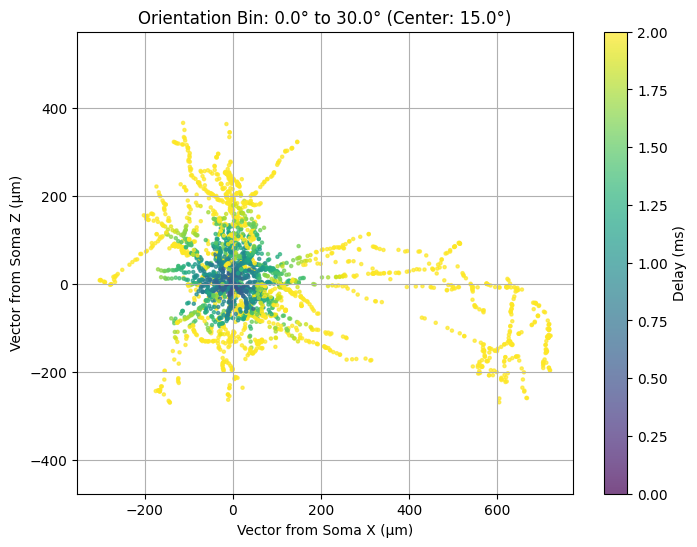

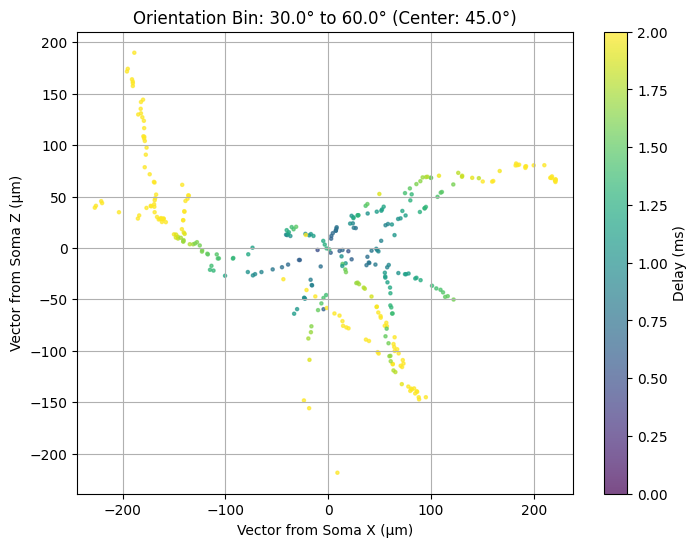

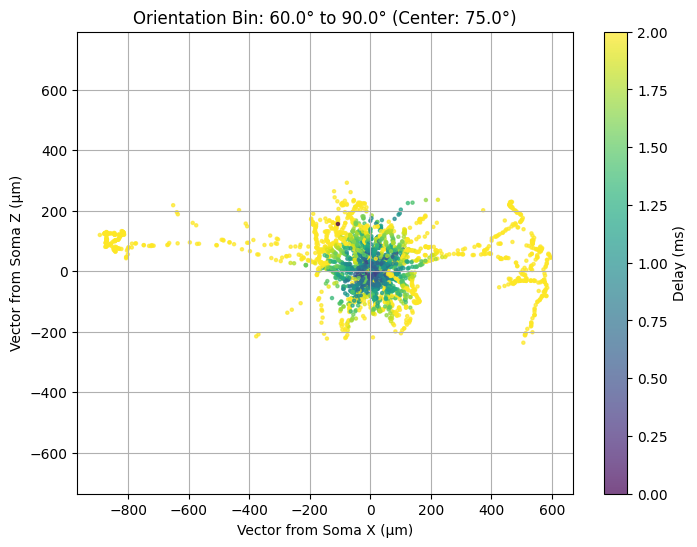

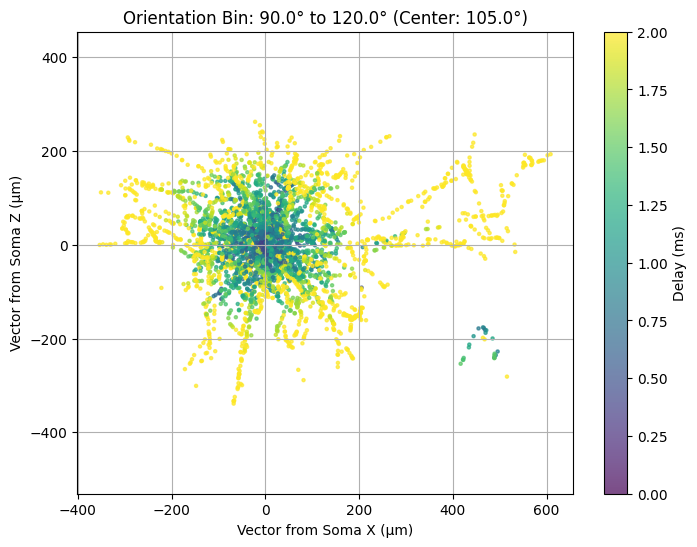

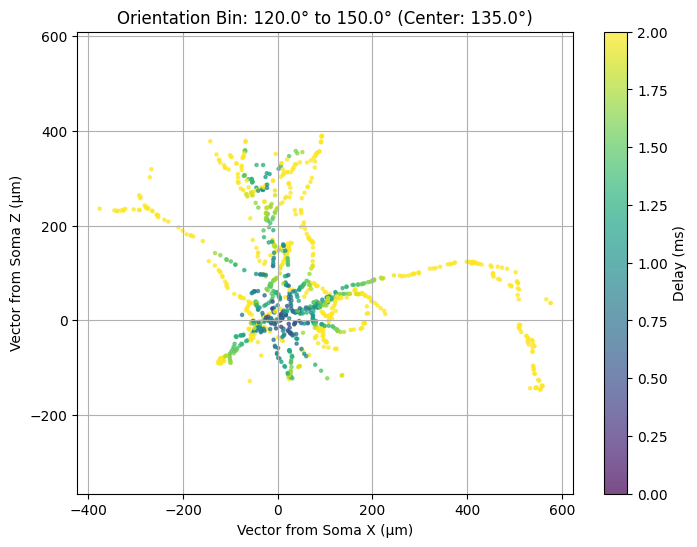

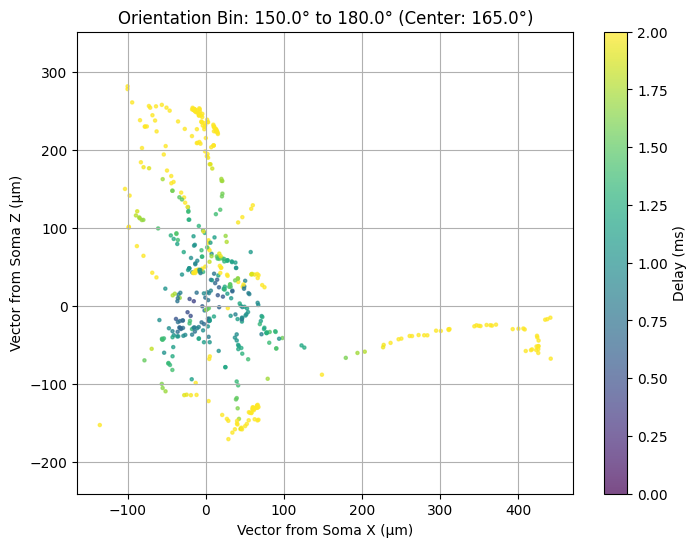

In [106]:
#0.2

OSI_thresh = 0.5
ori_bins = 6

#filter for high osi.
pt_root_ids_high_osi = digital_twin_coreg_df[digital_twin_coreg_df['OSI'] > OSI_thresh]['pt_root_id'].tolist()
filtered_df = synapse_delay_df[synapse_delay_df['pre_pt_root_id'].isin(pt_root_ids_high_osi)]

#for only known excitatory and inhibitory post synaptic neurons.
filtered_df = filtered_df[
    filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

#filter for cell type.
cell_types_to_include = ['4P']  # Example cell types
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

print(filtered_df.shape)

#For each bin, make a 2d scatter plot of "vector_from_soma" for each synapse (only showing x and z coordinates).
ori_bin_edges = np.linspace(0, 180, ori_bins + 1)
ori_bin_centers = (ori_bin_edges[:-1] + ori_bin_edges[1:]) / 2

for i in range(ori_bins):
    bin_min = ori_bin_edges[i]
    bin_max = ori_bin_edges[i + 1]

    # Get point IDs in this orientation bin
    pt_root_ids_in_bin = digital_twin_coreg_df[
        (digital_twin_coreg_df['pref_ori'] >= bin_min) &
        (digital_twin_coreg_df['pref_ori'] < bin_max)
    ]['pt_root_id'].tolist()
    
    # Filter by pre-synaptic root IDs
    bin_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_in_bin)].copy()

    # Extract x and z from vector_from_soma (assuming it’s a list-like [x, y, z])
    bin_df['x'] = bin_df['vector_from_soma'].apply(lambda v: v[0] if isinstance(v, (list, np.ndarray)) else np.nan)
    bin_df['z'] = bin_df['vector_from_soma'].apply(lambda v: v[2] if isinstance(v, (list, np.ndarray)) else np.nan)

    # Scatter plot: X vs Z
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        bin_df['x'],
        bin_df['z'],
        c=bin_df['delay'],       # Color by delay
        cmap='viridis',          # Choose a perceptually uniform colormap
        vmin=0,   # Fix color range minimum
        vmax=2,
        s=5,
        alpha=0.7
    )
    plt.colorbar(sc, label='Delay (ms)')
    plt.title(f'Orientation Bin: {bin_min:.1f}° to {bin_max:.1f}° (Center: {ori_bin_centers[i]:.1f}°)')
    plt.xlabel('Vector from Soma X (µm)')
    plt.ylabel('Vector from Soma Z (µm)')
    plt.axis('equal')
    plt.grid(True)
    plt.show()




Unique pre_pt_root_ids in filtered_df: 33
Unique pre_pt_root_ids in filtered_df: 6
Unique pre_pt_root_ids in bin 0 (0.0-90.0): 0


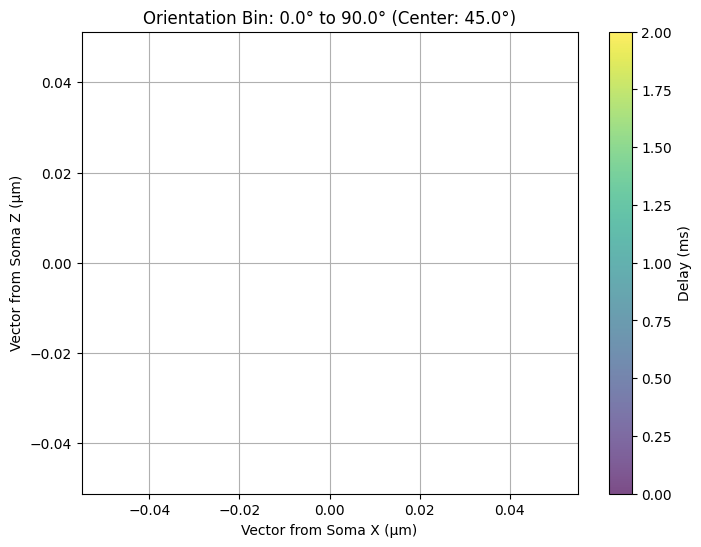

Unique pre_pt_root_ids in bin 1 (90.0-180.0): 3


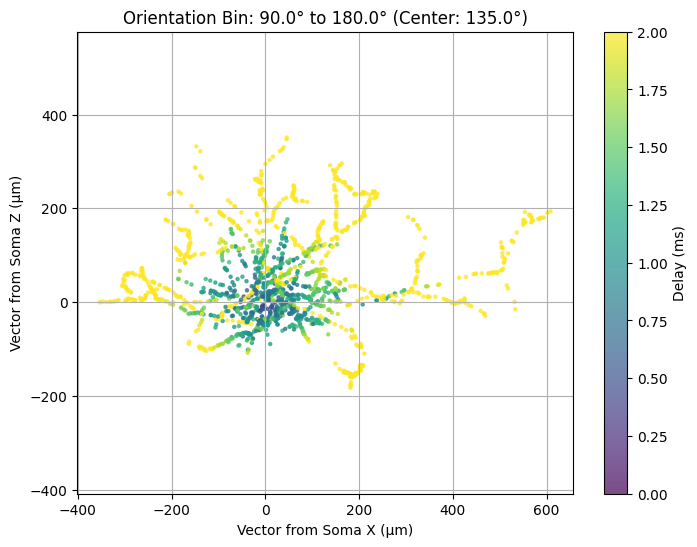

Unique pre_pt_root_ids in bin 2 (180.0-270.0): 1


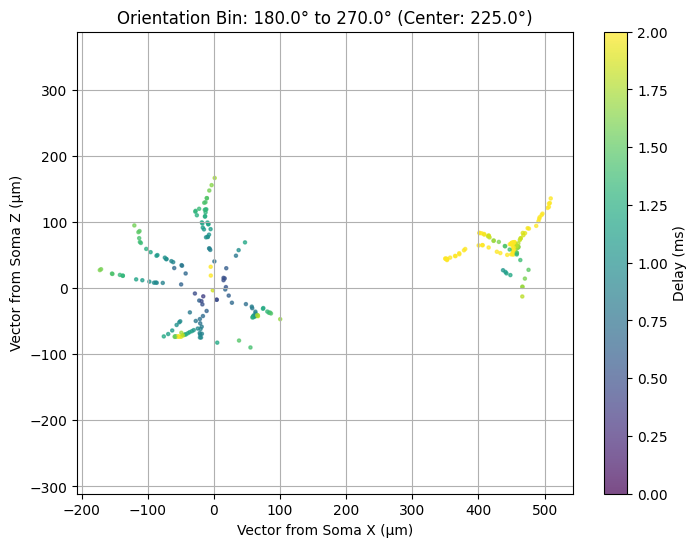

Unique pre_pt_root_ids in bin 3 (270.0-360.0): 3


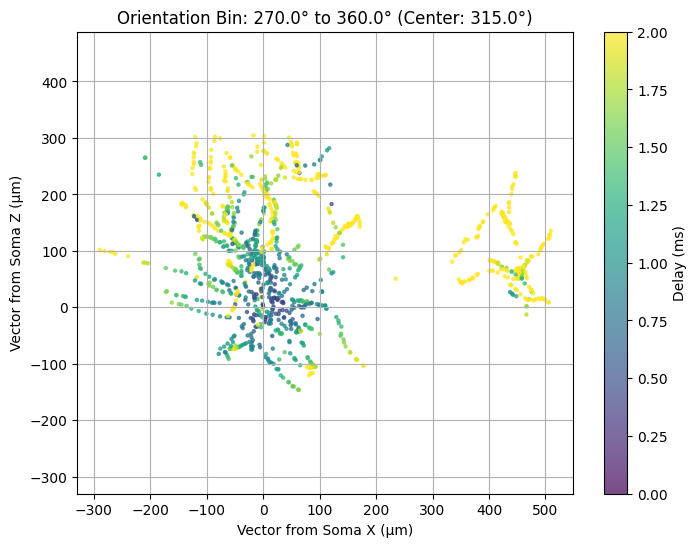

IndexError: index 5 is out of bounds for axis 0 with size 5

In [111]:
#0.3

DSI_thresh = 0.5
dir_bins = 4

#filter for high osi.
pt_root_ids_high_dsi = digital_twin_coreg_df[digital_twin_coreg_df['DSI'] > DSI_thresh]['pt_root_id'].tolist()
filtered_df = synapse_delay_df[synapse_delay_df['pre_pt_root_id'].isin(pt_root_ids_high_dsi)]

#How many unique pt_root_ids in filtered_df?
print(f"Unique pre_pt_root_ids in filtered_df: {filtered_df['pre_pt_root_id'].nunique()}")

#for only known excitatory and inhibitory post synaptic neurons.
# filtered_df = filtered_df[
#     filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
# ]

#filter for cell type.
cell_types_to_include = ['4P']  # Example cell types
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

print(f"Unique pre_pt_root_ids in filtered_df: {filtered_df['pre_pt_root_id'].nunique()}")

#For each bin, make a 2d scatter plot of "vector_from_soma" for each synapse (only showing x and z coordinates).
ori_bin_edges = np.linspace(0, 360, dir_bins + 1)
ori_bin_centers = (ori_bin_edges[:-1] + ori_bin_edges[1:]) / 2

for i in range(ori_bins):
    bin_min = ori_bin_edges[i]
    bin_max = ori_bin_edges[i + 1]

    # Get point IDs in this orientation bin
    pt_root_ids_in_bin = digital_twin_coreg_df[
        (digital_twin_coreg_df['pref_dir'] >= bin_min) &
        (digital_twin_coreg_df['pref_dir'] < bin_max)
    ]['pt_root_id'].tolist()
    
    # Filter by pre-synaptic root IDs
    bin_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_in_bin)].copy()
    #print unique pre_pt_root_ids in this bin
    print(f"Unique pre_pt_root_ids in bin {i} ({bin_min}-{bin_max}): {bin_df['pre_pt_root_id'].nunique()}") 

    # Extract x and z from vector_from_soma (assuming it’s a list-like [x, y, z])
    bin_df['x'] = bin_df['vector_from_soma'].apply(lambda v: v[0] if isinstance(v, (list, np.ndarray)) else np.nan)
    bin_df['z'] = bin_df['vector_from_soma'].apply(lambda v: v[2] if isinstance(v, (list, np.ndarray)) else np.nan)

    # Scatter plot: X vs Z
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        bin_df['x'],
        bin_df['z'],
        c=bin_df['delay'],       # Color by delay
        cmap='viridis',          # Choose a perceptually uniform colormap
        vmin=0,   # Fix color range minimum
        vmax=2,
        s=5,
        alpha=0.7
    )
    plt.colorbar(sc, label='Delay (ms)')
    plt.title(f'Orientation Bin: {bin_min:.1f}° to {bin_max:.1f}° (Center: {ori_bin_centers[i]:.1f}°)')
    plt.xlabel('Vector from Soma X (µm)')
    plt.ylabel('Vector from Soma Z (µm)')
    plt.axis('equal')
    plt.grid(True)
    plt.show()




# Excit/inhib distance_from_soma Analyses

In [34]:
#print list of unique post_cell_types in synapse_delay_df
print(synapse_delay_df['post_cell_type'].unique())

['BC' 'unknown' '6P-IT' 'MC' '5P-NP' '6P-CT' '5P-ET' '4P' '5P-IT' '23P'
 'NGC' 'BPC' 'OPC' 'microglia' 'astrocyte' 'oligo' 'pericyte']


In [63]:
#Not limited to column:
cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')
# column_df = client.materialize.query_table('allen_v1_column_types_slanted_ref')

#Combine all the synapse_len_delay_1507 files that are in column_df into a single dataframe.
synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
            syn_df = pickle.load(f)
            synapse_delay_list.append(syn_df)
        synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

print(len(synapse_delay_df))

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The beha

392778


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)
/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/1970141333.py:13: FutureWarning: The beha

19735


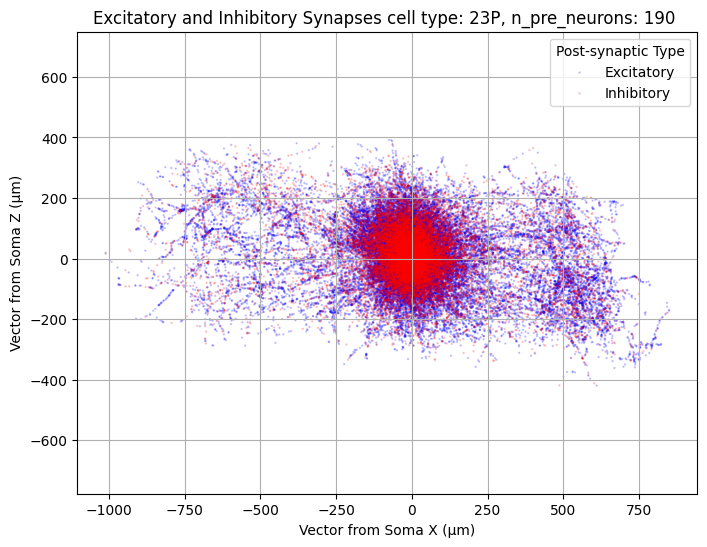

In [112]:

filtered_df = synapse_delay_df.copy()

# Keep only known excitatory and inhibitory post-synaptic neurons
filtered_df = filtered_df[
    filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

cell_types_to_include = ['23P']  # Example cell types
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
print(len(pt_root_ids_to_include))

filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

n_unique_pre = filtered_df['pre_pt_root_id'].nunique()

# Define color mapping
color_map = {
    'excitatory_neuron': 'blue',
    'inhibitory_neuron': 'red'
}

# Extract x and z from vector_from_soma (assuming list-like [x, y, z])
filtered_df['x'] = filtered_df['vector_from_soma'].apply(
    lambda v: v[0] if isinstance(v, (list, np.ndarray)) else np.nan
)
filtered_df['z'] = filtered_df['vector_from_soma'].apply(
    lambda v: v[2] if isinstance(v, (list, np.ndarray)) else np.nan
)

# Map colors based on post_excit_inhib
filtered_df['color'] = filtered_df['post_excit_inhib'].map(color_map)

filtered_df = filtered_df.sample(frac=1, random_state=0).reset_index(drop=True)

# Scatter plot: X vs Z, colored by inhibitory/excitatory
plt.figure(figsize=(8, 6))
for cell_type, sub_df in filtered_df.groupby('post_excit_inhib'):
    plt.scatter(
        sub_df['x'], sub_df['z'],
        c=sub_df['color'],
        s=.5,
        # alpha=0.5,
        alpha=0.2,
        label=cell_type.replace('_neuron', '').capitalize()
    )

plt.title(f'Excitatory and Inhibitory Synapses cell type: {", ".join(cell_types_to_include)}, n_pre_neurons: {n_unique_pre} ')
plt.xlabel('Vector from Soma X (µm)')
plt.ylabel('Vector from Soma Z (µm)')
plt.axis('equal')
plt.grid(True)
plt.legend(title="Post-synaptic Type")
plt.show()


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/283518017.py:62: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



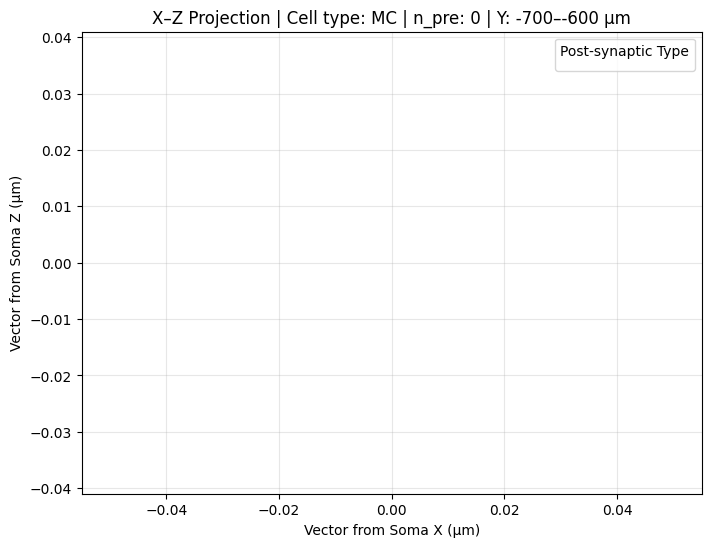

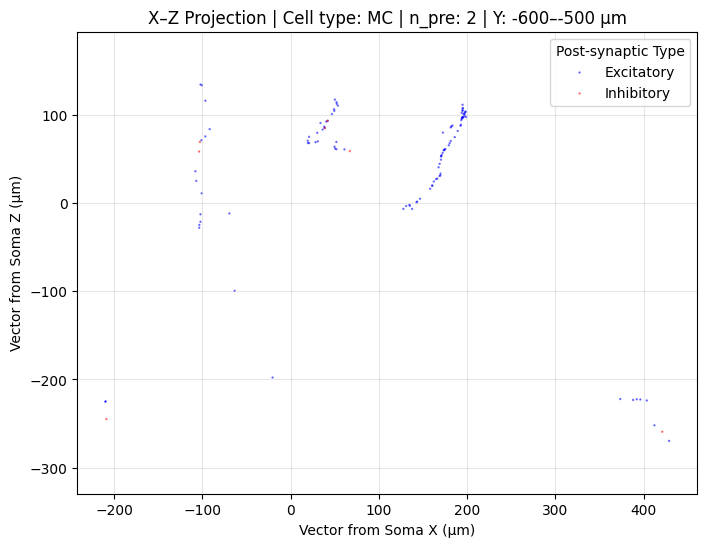

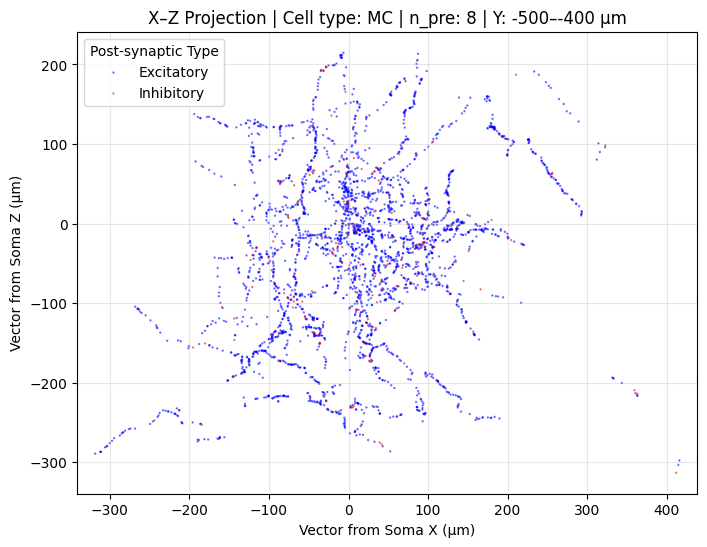

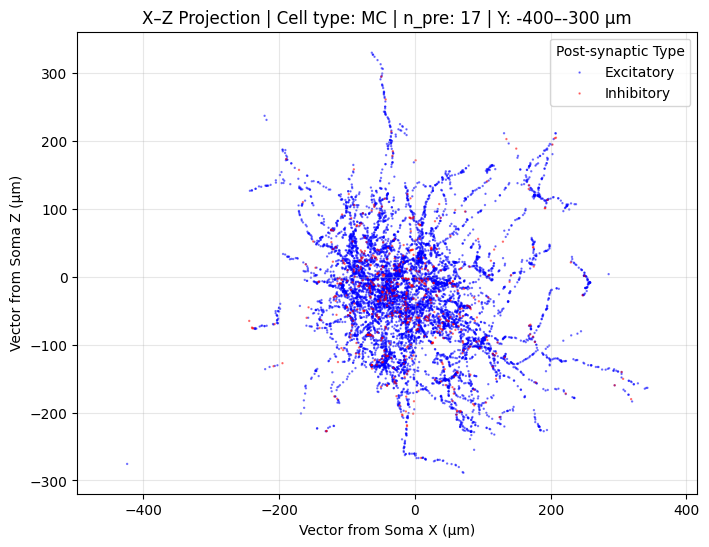

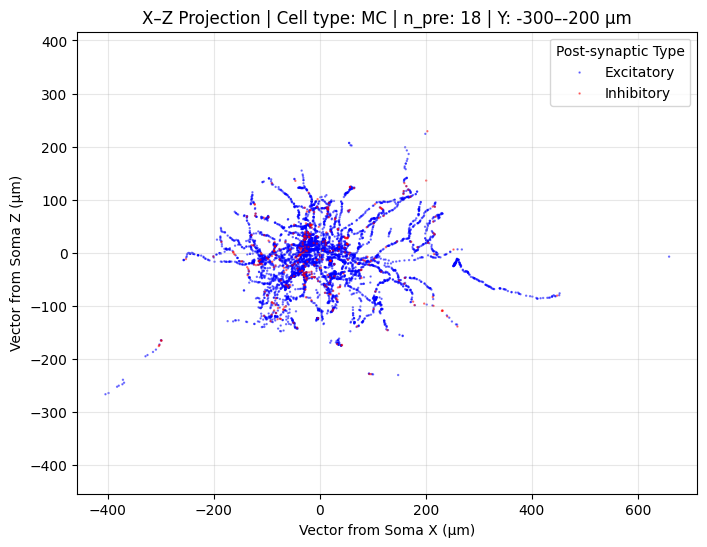

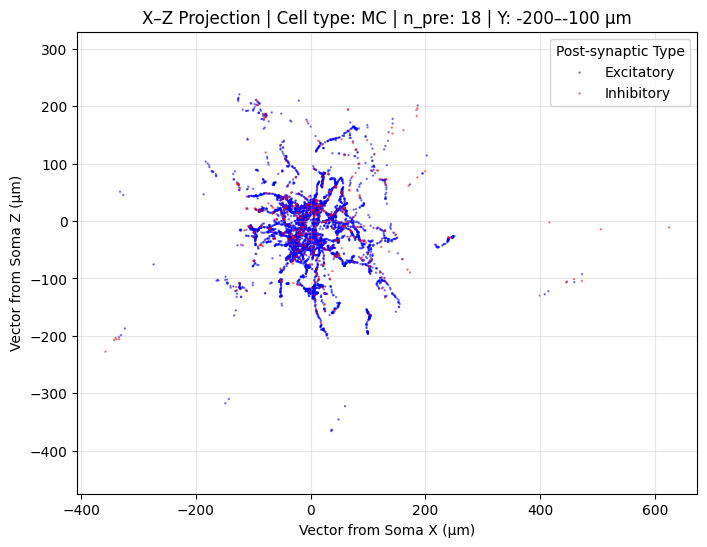

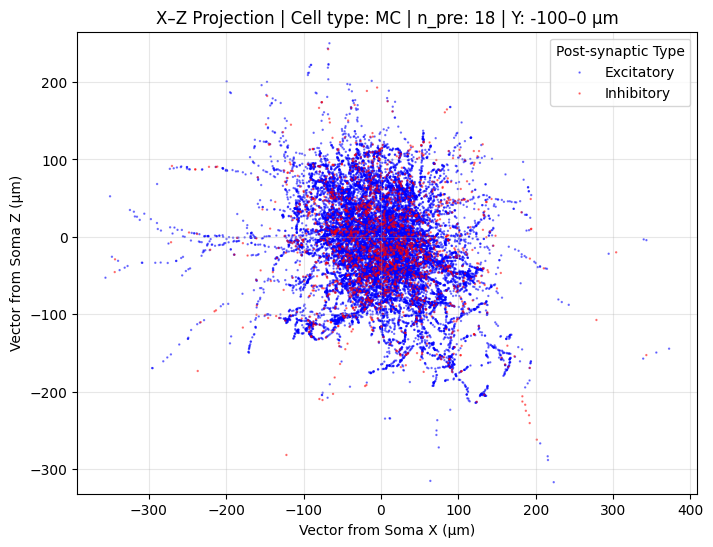

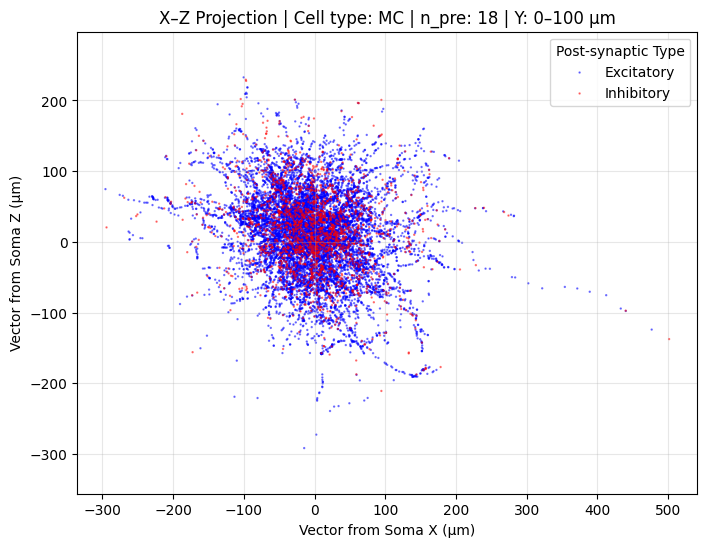

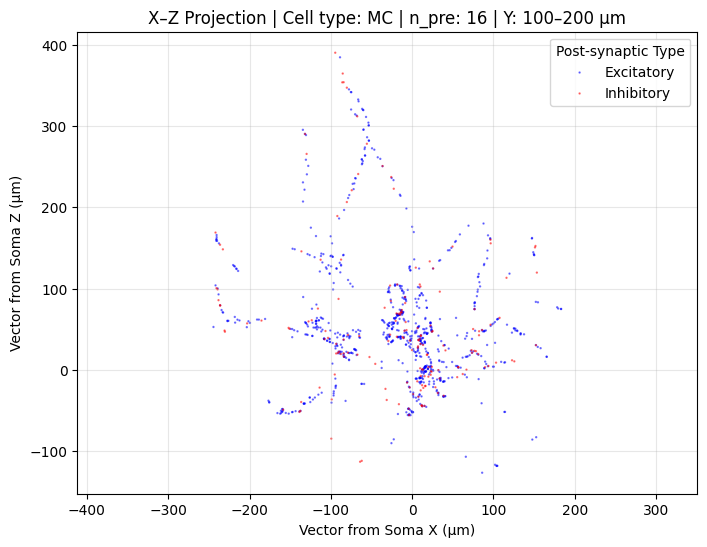

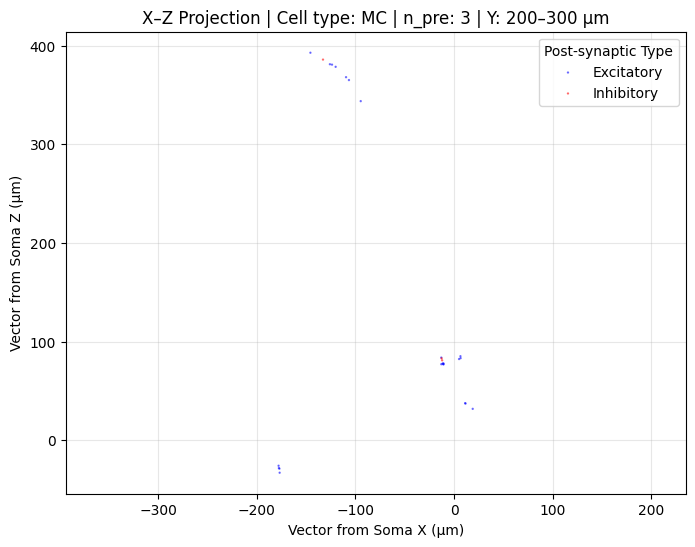

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/283518017.py:62: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



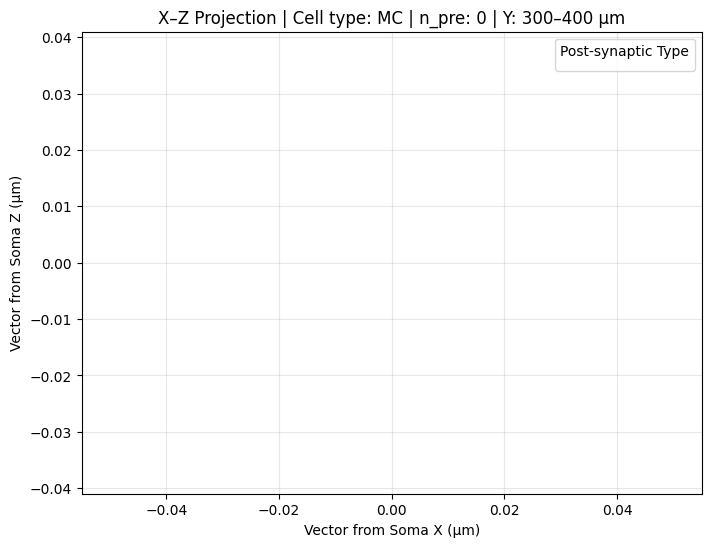

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/283518017.py:62: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



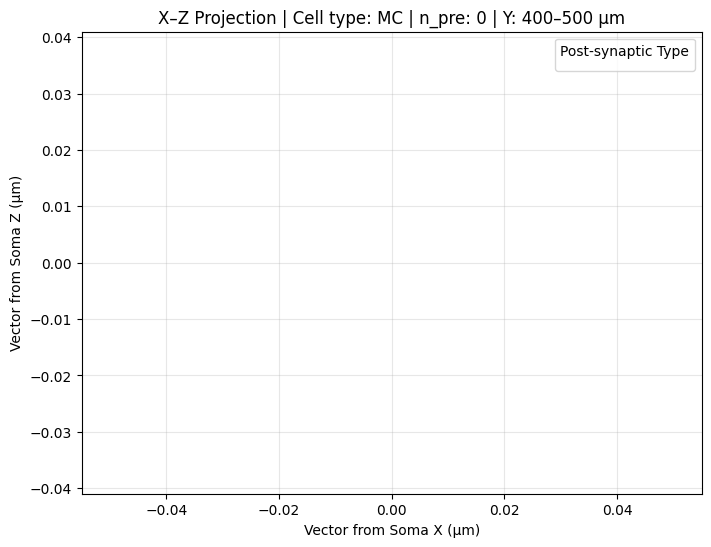

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/283518017.py:62: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



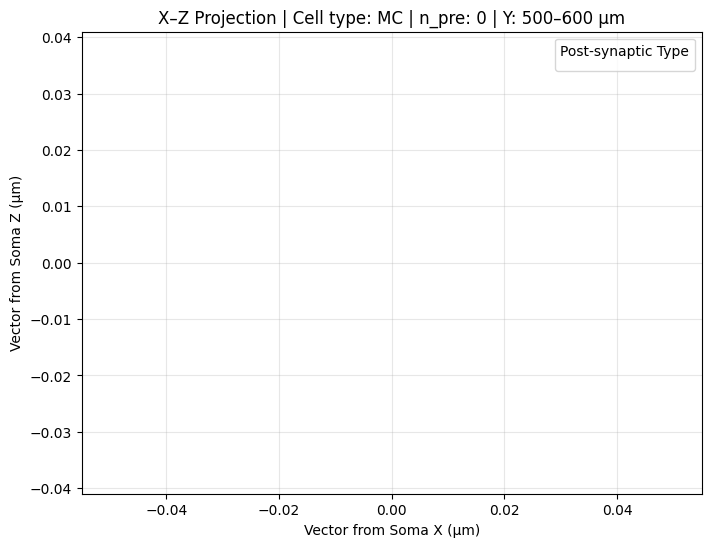

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/283518017.py:62: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



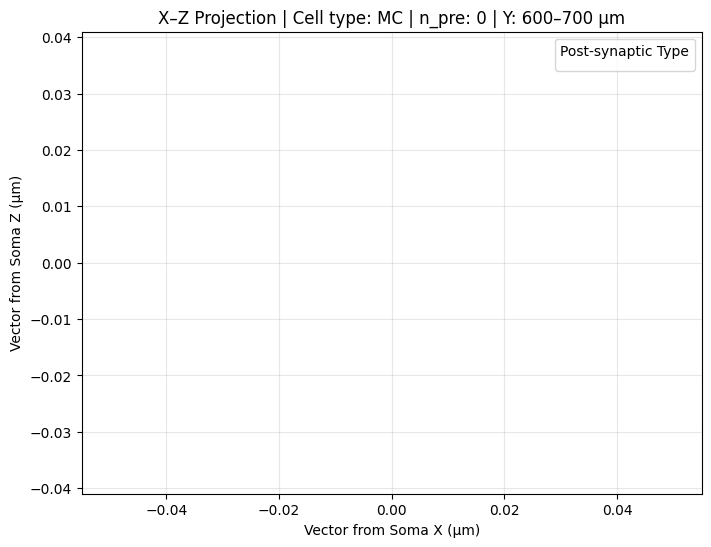

In [114]:

# --- Data filtering setup ---

filtered_df = synapse_delay_df.copy()

# Keep only known excitatory and inhibitory post-synaptic neurons
filtered_df = filtered_df[
    filtered_df['post_excit_inhib'].isin(['excitatory_neuron', 'inhibitory_neuron'])
]

cell_types_to_include = ['MC']  # example cell types
pt_root_ids_to_include = cell_type_df[
    cell_type_df['cell_type'].isin(cell_types_to_include)
]['pt_root_id'].tolist()

filtered_df = filtered_df[filtered_df['pre_pt_root_id'].isin(pt_root_ids_to_include)]

# Extract x, y, z
filtered_df['x'] = filtered_df['vector_from_soma'].apply(lambda v: v[0] if isinstance(v, (list, np.ndarray)) else np.nan)
filtered_df['y'] = filtered_df['vector_from_soma'].apply(lambda v: v[1] if isinstance(v, (list, np.ndarray)) else np.nan)
filtered_df['z'] = filtered_df['vector_from_soma'].apply(lambda v: v[2] if isinstance(v, (list, np.ndarray)) else np.nan)

# Map colors
color_map = {'excitatory_neuron': 'blue', 'inhibitory_neuron': 'red'}
filtered_df['color'] = filtered_df['post_excit_inhib'].map(color_map)

# Shuffle for fair rendering order
filtered_df = filtered_df.sample(frac=1, random_state=0).reset_index(drop=True)

# --- Slice parameters ---
y_min, y_max = -700, 700       # range to scan (µm)
slice_thickness = 100          # slice thickness (µm)
slice_step = 100               # distance between slice starts (µm)

y_starts = np.arange(y_min, y_max, slice_step)

# --- Loop through slices ---
for y_start in y_starts:
    y_end = y_start + slice_thickness
    slice_df = filtered_df[(filtered_df['y'] >= y_start) & (filtered_df['y'] < y_end)]

    # Number of unique presynaptic neurons in this slice
    n_unique_pre = slice_df['pre_pt_root_id'].nunique()

    plt.figure(figsize=(8, 6))
    for cell_type, sub_df in slice_df.groupby('post_excit_inhib'):
        plt.scatter(
            sub_df['x'], sub_df['z'],
            c=sub_df['color'],
            s=0.5,
            alpha=0.5,
            label=cell_type.replace('_neuron', '').capitalize()
        )

    plt.title(
        f'X–Z Projection | Cell type: {", ".join(cell_types_to_include)} | '
        f'n_pre: {n_unique_pre} | Y: {y_start:.0f}–{y_end:.0f} µm'
    )
    plt.xlabel('Vector from Soma X (µm)')
    plt.ylabel('Vector from Soma Z (µm)')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend(title="Post-synaptic Type", loc='best')
    plt.show()


In [66]:
#3.33_intermission Let's look at how ratio of excitatory to inhibitory synapses changes with delay of synapses.
#Do this for a given set of cell types: ["23P", "4P", "5P-IT", "5P-ET", "BC", "MC"]
#Want bins of .5 milliseconds. So 0 - .5, .5 - 1, 1 - 1.5, etc.
#For each bin, for each cell type (different color for each) put a point for ratio of exc to inh synapses.


cell_types_to_include = ["23P", "4P", "5P-IT", "5P-ET", "BC", "MC"]

# Get pt_root_ids for the included cell types
pt_root_ids_to_include = cell_type_df[
    cell_type_df["cell_type"].isin(cell_types_to_include)
][["pt_root_id", "cell_type"]]

# Merge to attach cell type to each synapse
merged_df = synapse_delay_df.merge(
    pt_root_ids_to_include, how="inner", left_on="pre_pt_root_id", right_on="pt_root_id"
)

# Remove unknown synapses
merged_df = merged_df[
    merged_df["post_excit_inhib"].isin(["excitatory_neuron", "inhibitory_neuron"])
]

# Define delay bins (0.5 ms bins)
bin_edges = np.arange(0, merged_df["delay"].max() + 0.5, 0.5)
merged_df["delay_bin"] = pd.cut(merged_df["delay"], bins=bin_edges, right=False)

# Compute ratio of excitatory to inhibitory per bin per cell type
ratio_df = (
    merged_df.groupby(["cell_type", "delay_bin"])["post_excit_inhib"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

# Compute ratio safely (avoid division by zero)
ratio_df["exc_to_inh_ratio"] = ratio_df.apply(
    lambda row: row.get("excitatory_neuron", 0)
    / row.get("inhibitory_neuron", np.nan)
    if row.get("inhibitory_neuron", 0) > 0
    else np.nan,
    axis=1,
)

# Midpoints for plotting
ratio_df["delay_bin_center"] = ratio_df["delay_bin"].apply(lambda x: x.mid)

# Plot: excitatory/inhibitory ratio vs. delay bin, colored by cell type
fig = px.scatter(
    ratio_df,
    x="delay_bin_center",
    y="exc_to_inh_ratio",
    color="cell_type",
    title="Excitatory/Inhibitory Synapse Ratio vs. Delay (per Cell Type)",
    labels={
        "delay_bin_center": "Delay (ms)",
        "exc_to_inh_ratio": "Exc/Inh Ratio",
    },
)

fig.update_traces(mode="markers+lines")
fig.update_layout(
    xaxis=dict(tickmode="linear", tick0=0, dtick=0.5,range=[0, 8]),
    yaxis=dict(title="Excitatory/Inhibitory Ratio", rangemode="tozero",range=[0, 15]),
    # yaxis=dict(title="Excitatory/Inhibitory Ratio", rangemode="tozero",range=[-1, 1.5],type="log"),
)
fig.show()


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_13778/3146159365.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [55]:
print(len(pt_root_ids_to_include))

3365


In [59]:
#go through pt_root_ids_to_include, and see if the updated is same or different

#get pt_root_ids in column_df
pt_root_ids_in_column = column_df['pt_root_id'].tolist()

# pt_root_ids = pt_root_ids_to_include
pt_root_ids = pt_root_ids_in_column


for i in range(len(pt_root_ids)):
    print(i)
    if pt_root_ids[i] == 0:
        continue
    updated_id = client.chunkedgraph.get_root_id(pt_root_ids[i])
    if updated_id != pt_root_ids[i]:
        print(f"Original ID: {pt_root_ids[i]}, Updated ID: {updated_id}")



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
#Get cell types of pt_root_ids_in_column
cell_types_in_column = cell_type_df[cell_type_df['pt_root_id'].isin(pt_root_ids_in_column)][['pt_root_id', 'cell_type']]

#print unique cell type counts:
print(cell_types_in_column['cell_type'].value_counts())




cell_type
23P      343
4P       281
6P-IT    214
6P-CT    151
5P-IT    141
BC        62
MC        44
5P-ET     42
BPC       36
5P-NP     11
NGC       10
Name: count, dtype: int64


In [62]:
pt_root_ids = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in column_df['pt_root_id'].tolist():
            pt_root_ids.append(pt_root_id)

#Get cell types of pt_root_ids_in_column
cell_types_in_extracted_syns= cell_type_df[cell_type_df['pt_root_id'].isin(pt_root_ids)][['pt_root_id', 'cell_type']]

#print unique cell type counts:
print(cell_types_in_extracted_syns['cell_type'].value_counts())

cell_type
23P      112
5P-IT     46
4P        21
6P-IT     16
MC         9
5P-ET      8
6P-CT      7
BC         2
5P-NP      1
BPC        1
Name: count, dtype: int64
